# Problema de la mochila
Hugo André Meza Fierros

A00841695

## Problema 1

Un armador tiene un carguero con capacidad de hasta 700 toneladas. El carguero transporta contenedores de diferentes pesos para una determinada ruta. En la ruta actual el carguero puede transportar algunos de los siguientes contenedores:

| Contenedor | $c_1$ | $c_2$ |  $c_3$ |  $c_4$ |  $c_5$ |  $c_6$ |  $c_7$ |  $c_8$ |  $c_9$ |  $c_{10}$ | 
 --------- | --------- | --------- | --------- | --------- | --------- | --------- | --------- | --------- | --------- | --------- |
| Peso(ton) | 100 | 155 | 50 | 112 | 70 | 80 | 60 | 118 | 110 | 55 |
| Beneficio [\$ /ton] | 1741 | 1622 | 1016 | 1264 | 1305 | 1389 | 1797 | 1330 | 1559 | 1578 |

El analista de la empresa del armador desea determinar el envío (conjunto de contenedores) que maximiza el beneficio.

### Modelo matemático (método exacto)

In [ ]:
from docplex.mp.model import Model

In [ ]:
T = 700
I = range(1, 11)
w = [100, 155, 50, 112, 70, 80, 60, 118, 110, 55]
c = [1741, 1622, 1016, 1264, 1305, 1389, 1797, 1330, 1559, 1578]


In [ ]:
mdl = Model('Mochila')

x = mdl.binary_var_list(I, name='x') # variable de decisión

mdl.maximize(mdl.sum(c[i-1] * w[i-1] * x[i-1] for i in I)) # Función objetivo

mdl.add_constraint(mdl.sum(w[i-1] * x[i-1] for i in I) <= T, ctname='r_capacidad') # Restricción de capacidad

docplex.mp.LinearConstraint[r_capacidad](100x_1+155x_2+50x_3+112x_4+70x_5+80x_6+60x_7+118x_8+110x_9+55x_10,LE,700)

In [ ]:
solucion = mdl.solve()

if solucion:
    # 1. Valor de la función objetivo Z
    valor_objetivo = solucion.objective_value
    
    # Obtener el objeto de detalles del solver
    detalles = mdl.get_solve_details()
    
    # 2. Tiempo computacional y número de iteraciones
    tiempo_cpu = detalles.time
    num_iteraciones = detalles.nb_iterations

    # 3. Solución factible (Contenedores donde x_i = 1)
    # x[i].solution_value da el valor asignado a la variable en la solución
    seleccionados = [i for i in I if x[i-1].solution_value > 0.5]

    # 4. Capacidad ocupada (Suma de pesos de los contenedores seleccionados)
    capacidad_ocupada = sum(w[i] for i in seleccionados)
    porcentaje_ocupacion = (capacidad_ocupada / T) * 100

    # Imprimir reporte completo
    print("=" * 45)
    print("       REPORTE DE MÉTRICAS DE EJECUCIÓN (CPLEX)")
    print("=" * 45)
    print(f"Función Objetivo (Z) : ${valor_objetivo:,.2f}")
    print(f"Solución Factible (S): Contenedores {seleccionados}")
    print(f"Capacidad Ocupada    : {capacidad_ocupada} / {T} ton ({porcentaje_ocupacion:.1f}%)")
    print(f"Tiempo Computacional : {tiempo_cpu:.6f} segundos")
    print(f"Número de Iteraciones: {num_iteraciones}")
    print("=" * 45)
else:
    print("No se encontró una solución factible.")

       REPORTE DE MÉTRICAS DE EJECUCIÓN (CPLEX)
• Función Objetivo (Z) : $1,064,230.00
• Solución Factible (S): Contenedores [1, 2, 5, 6, 7, 8, 9]
• Capacidad Ocupada    : 693 / 700 ton (99.0%)
• Tiempo Computacional : 0.000000 segundos
• Número de Iteraciones: 5


### Heurístico a mano

In [ ]:
import time

# Datos
w = {1: 100, 2: 155, 3: 50, 4: 112, 5: 70, 6: 80, 7: 60, 8: 118, 9: 110, 10: 55}
c = {1: 1741, 2: 1622, 3: 1016, 4: 1264, 5: 1305, 6: 1389, 7: 1797, 8: 1330, 9: 1559, 10: 1578}
T = 700

start_time = time.perf_counter()
ratio = {i: w[i] / c[i] for i in w}

ordenados = sorted(ratio.keys(), key=lambda i: ratio[i])

capacidad_restante = T
Z_heuristico = 0
seleccionados = []
iteraciones = 0

for i in ordenados:
    iteraciones += 1
    if w[i] <= capacidad_restante:
        seleccionados.append(i)
        capacidad_restante -= w[i]
        Z_heuristico += w[i] * c[i]

end_time = time.perf_counter()
tiempo_ejecucion = end_time - start_time

print("=" * 45)
print("     MÉTRICAS DEL HEURÍSTICO")
print("=" * 45)
print(f"• Función Objetivo (Z) : ${Z_heuristico:,.2f}")
print(f"• Tiempo Computacional : {tiempo_ejecucion:.8f} segundos")
print(f"• Número de Iteraciones: {iteraciones}")
print(f"• Contenedores Usados  : {seleccionados}")
print(f"• Peso Total Cargado   : {T - capacidad_restante} / {T} ton")
print("=" * 45)

     MÉTRICAS DEL HEURÍSTICO
• Función Objetivo (Z) : $935,038.00
• Tiempo Computacional : 0.00016420 segundos
• Número de Iteraciones: 10
• Contenedores Usados  : [7, 10, 3, 5, 1, 6, 9, 4]
• Peso Total Cargado   : 637 / 700 ton


# Extensión del problema

In [8]:
from docplex.mp.model import Model
import numpy as np
import pandas as pd

# Cargar el archivo Excel
df = pd.read_excel('../data/mochila_1.xlsx', sheet_name='Hoja2', header=None)

instancias = []
i = 0

while i < len(df):
    val = str(df.iloc[i, 0]).strip()
    if val == 'Contenedor':
        # Filas: Header (ítems), Pesos, Beneficios
        items = df.iloc[i].dropna().tolist()[1:]
        pesos = [float(x) for x in df.iloc[i + 1].dropna().tolist()[1:]]
        beneficios = [float(x) for x in df.iloc[i + 2].dropna().tolist()[1:]]

        instancias.append({
            'id': len(instancias) + 1,
            'num_items': len(items),
            'contenedores': items,
            'pesos': np.array(pesos, dtype=float),
            'beneficios': np.array(beneficios, dtype=float),
        })
        i += 3
    else:
        i += 1

# Ejemplo: Mostrar la primera instancia
instancia_1 = instancias[0]
print(f"Instancia {instancia_1['id']} ({instancia_1['num_items']} ítems):")
print("Vector de Pesos (w):", instancia_1['pesos'])
print("Vector de Beneficios (v):", instancia_1['beneficios'])

Instancia 1 (10 ítems):
Vector de Pesos (w): [106.  76.  62. 118. 117. 109. 114.  87.  89. 104.]
Vector de Beneficios (v): [1649. 1371. 1558. 1685. 1611. 1464. 1152. 1672. 1510. 1083.]


## Modelo matemático

In [26]:
T = 700
valor_objetivo = []
seleccionados = []
capacidad_ocupada = []
tiempo_cpu = []
num_iteraciones = []

for instancia in instancias:
    I = range(1, len(instancia['contenedores']) + 1)
    mdl = Model(f'Mochila{instancia["id"]}')
    c = instancia['beneficios']
    w = instancia['pesos']

    x = mdl.binary_var_list(I, name='x') # variable de decisión

    mdl.maximize(mdl.sum(c[i-1] * w[i-1] * x[i-1] for i in I)) # Función objetivo

    mdl.add_constraint(mdl.sum(w[i-1] * x[i-1] for i in I) <= T, ctname='r_capacidad') # Restricción de capacidad
    solucion = mdl.solve()

    if solucion:
        # 1. Valor de la función objetivo Z
        valor_objetivo.append(solucion.objective_value)
        
        # Obtener el objeto de detalles del solver
        detalles = mdl.get_solve_details()
        
        # 2. Tiempo computacional y número de iteraciones
        tiempo_cpu.append(detalles.time)
        num_iteraciones.append(detalles.nb_iterations)

        # 3. Solución factible (Contenedores donde x_i = 1)
        # x[i].solution_value da el valor asignado a la variable en la solución
        seleccionados.append([i for i in I if x[i-1].solution_value > 0.5])

        # 4. Capacidad ocupada (Suma de pesos de los contenedores seleccionados)
        capacidad_ocupada.append(sum(w[i - 1] for i in seleccionados[instancia['id'] - 1]))
        porcentaje_ocupacion = (capacidad_ocupada[instancia['id'] - 1] / T) * 100

        # Imprimir reporte completo
        print("=" * 45)
        print(f"       REPORTE DE MÉTRICAS DE EJECUCIÓN {instancia['id']}")
        print("=" * 45)
        print(f"Función Objetivo (Z) : ${valor_objetivo[instancia['id'] - 1]:,.2f}")
        print(f"Solución Factible (S): Contenedores {seleccionados[instancia['id'] - 1]}")
        print(f"Capacidad Ocupada    : {capacidad_ocupada[instancia['id'] - 1]} / {T} ton ({porcentaje_ocupacion:.1f}%)")
        print(f"Tiempo Computacional : {tiempo_cpu[instancia['id'] - 1]:.6f} segundos")
        print(f"Número de Iteraciones: {num_iteraciones[instancia['id'] - 1]}")
        print("=" * 45)
    else:
        print("No se encontró una solución factible.")

       REPORTE DE MÉTRICAS DE EJECUCIÓN 1
Función Objetivo (Z) : $1,098,137.00
Solución Factible (S): Contenedores [1, 3, 4, 5, 6, 8, 9]
Capacidad Ocupada    : 688.0 / 700 ton (98.3%)
Tiempo Computacional : 0.015000 segundos
Número de Iteraciones: 2
       REPORTE DE MÉTRICAS DE EJECUCIÓN 2
Función Objetivo (Z) : $1,136,636.00
Solución Factible (S): Contenedores [1, 3, 5, 6, 7, 8, 9, 10]
Capacidad Ocupada    : 700.0 / 700 ton (100.0%)
Tiempo Computacional : 0.016000 segundos
Número de Iteraciones: 4
       REPORTE DE MÉTRICAS DE EJECUCIÓN 3
Función Objetivo (Z) : $1,118,758.00
Solución Factible (S): Contenedores [1, 2, 4, 5, 6, 7, 9]
Capacidad Ocupada    : 693.0 / 700 ton (99.0%)
Tiempo Computacional : 0.015000 segundos
Número de Iteraciones: 6
       REPORTE DE MÉTRICAS DE EJECUCIÓN 4
Función Objetivo (Z) : $1,115,814.00
Solución Factible (S): Contenedores [1, 2, 3, 4, 5, 6, 8, 10]
Capacidad Ocupada    : 687.0 / 700 ton (98.1%)
Tiempo Computacional : 0.016000 segundos
Número de Iterac

## Heurístico

In [27]:
import time


T = 700

Z_heuristico = []
seleccionados_h = []
iteraciones_h = []
tiempo_ejecucion_h = []
capacidad_ocupada_h = []

for instancia in instancias:
    w = {i+1: instancia['pesos'][i] for i in range(instancia['num_items'])}
    c = {i+1: instancia['beneficios'][i] for i in range(instancia['num_items'])}

    start_time = time.perf_counter()
    ratio = {i: w[i] / c[i] for i in w}

    ordenados = sorted(ratio.keys(), key=lambda i: ratio[i])

    capacidad_restante = T

    s = []
    it = 0
    Z_h = 0
    for i in ordenados:
        it += 1
        if w[i] <= capacidad_restante:
            s.append(i)
            capacidad_restante -= w[i]
            Z_h += w[i] * c[i]


    end_time = time.perf_counter()
    tiempo_ejecucion_h.append(end_time - start_time)

    Z_heuristico.append(Z_h)
    seleccionados_h.append(s)
    iteraciones_h.append(it)
    capacidad_ocupada_h.append(T - capacidad_restante)

    print("=" * 45)
    print(f"     MÉTRICAS DEL HEURÍSTICO {instancia['id']}")
    print("=" * 45)
    print(f"• Función Objetivo (Z) : ${Z_heuristico[-1]:,.2f}")
    print(f"• Tiempo Computacional : {tiempo_ejecucion_h[-1]:.8f} segundos")
    print(f"• Número de Iteraciones: {iteraciones_h[-1]}")
    print(f"• Contenedores Usados  : {seleccionados_h[-1]}")
    print(f"• Peso Total Cargado   : {T - capacidad_restante} / {T} ton")
    print("=" * 45)

     MÉTRICAS DEL HEURÍSTICO 1
• Función Objetivo (Z) : $1,042,757.00
• Tiempo Computacional : 0.00001790 segundos
• Número de Iteraciones: 10
• Contenedores Usados  : [3, 8, 2, 9, 1, 4, 5]
• Peso Total Cargado   : 655.0 / 700 ton
     MÉTRICAS DEL HEURÍSTICO 2
• Función Objetivo (Z) : $1,088,044.00
• Tiempo Computacional : 0.00001130 segundos
• Número de Iteraciones: 10
• Contenedores Usados  : [3, 9, 7, 8, 2, 6, 10, 4]
• Peso Total Cargado   : 663.0 / 700 ton
     MÉTRICAS DEL HEURÍSTICO 3
• Función Objetivo (Z) : $1,118,758.00
• Tiempo Computacional : 0.00000620 segundos
• Número de Iteraciones: 10
• Contenedores Usados  : [5, 4, 1, 6, 9, 7, 2]
• Peso Total Cargado   : 693.0 / 700 ton
     MÉTRICAS DEL HEURÍSTICO 4
• Función Objetivo (Z) : $1,080,903.00
• Tiempo Computacional : 0.00000550 segundos
• Número de Iteraciones: 10
• Contenedores Usados  : [10, 6, 5, 3, 7, 8, 1, 2]
• Peso Total Cargado   : 662.0 / 700 ton
     MÉTRICAS DEL HEURÍSTICO 5
• Función Objetivo (Z) : $1,025,493.0

## Métricas

In [29]:
import numpy as np

dif_porcentual_Z = [
    round(((z_e - z_h) / z_e) * 100, 2) if z_e != 0 else 0
    for z_e, z_h in zip(valor_objetivo, Z_heuristico)
]

dif_porcentual_Tiempo = [
    round(((t_e - t_h) / t_e) * 100, 2) if t_e != 0 else 0
    for t_e, t_h in zip(tiempo_cpu, tiempo_ejecucion_h)
]

In [30]:
df_comparativo = pd.DataFrame({
    'Instancia': [f"Instancia {i+1}" for i in range(len(valor_objetivo))],
    'Z Modelo Exacto': valor_objetivo,
    'Z Heurístico': Z_heuristico,
    'Diferencia Z (%)': dif_porcentual_Z,
    'Tiempo Modelo (s)': tiempo_cpu,
    'Tiempo Heurístico (s)': tiempo_ejecucion_h,
    'Ahorro Tiempo (%)': dif_porcentual_Tiempo,
})

# Mostrar la tabla en consola
print("\n" + "="*80)
print("TABLA COMPARATIVA: MODELO MATEMÁTICO VS HEURÍSTICO PROPUESTO")
print("="*80)
print(df_comparativo.to_string(index=False))




TABLA COMPARATIVA: MODELO MATEMÁTICO VS HEURÍSTICO PROPUESTO
   Instancia  Z Modelo Exacto  Z Heurístico  Diferencia Z (%)  Tiempo Modelo (s)  Tiempo Heurístico (s)  Ahorro Tiempo (%)
 Instancia 1        1098137.0     1042757.0              5.04              0.015               0.000018              99.88
 Instancia 2        1136636.0     1088044.0              4.28              0.016               0.000011              99.93
 Instancia 3        1118758.0     1118758.0              0.00              0.015               0.000006              99.96
 Instancia 4        1115814.0     1080903.0              3.13              0.016               0.000006              99.97
 Instancia 5        1025493.0     1025493.0              0.00              0.063               0.000005              99.99
 Instancia 6        1085902.0     1085902.0              0.00              0.015               0.000005              99.97
 Instancia 7        1044607.0      925027.0             11.45              0.

In [31]:
import matplotlib.pyplot as plt

df_resumen = pd.DataFrame({
    'Métrica': ['Valor Objetivo (Z)', 'Tiempo CPU (s)'],
    'Promedio Modelo Exacto': [np.mean(valor_objetivo), np.mean(tiempo_cpu)],
    'Promedio Heurístico': [np.mean(Z_heuristico), np.mean(tiempo_ejecucion_h)],
    'Diferencia Promedio (%)': [
        np.mean(dif_porcentual_Z),
        np.mean(dif_porcentual_Tiempo),
    ],
    'Diferencia Máxima (%)': [
        np.max(dif_porcentual_Z),
        np.max(dif_porcentual_Tiempo),
    ],
    'Diferencia Mínima (%)': [
        np.min(dif_porcentual_Z),
        np.min(dif_porcentual_Tiempo),
    ],
})

print("\n" + "="*80)
print("RESUMEN ESTADÍSTICO GENERAL")
print("="*80)
print(df_resumen.to_string(index=False))


RESUMEN ESTADÍSTICO GENERAL
           Métrica  Promedio Modelo Exacto  Promedio Heurístico  Diferencia Promedio (%)  Diferencia Máxima (%)  Diferencia Mínima (%)
Valor Objetivo (Z)            1.168995e+06         1.084909e+06                 7.114828                  13.96                    0.0
    Tiempo CPU (s)            6.745862e-01         8.041379e-06                93.072759                 100.00                    0.0


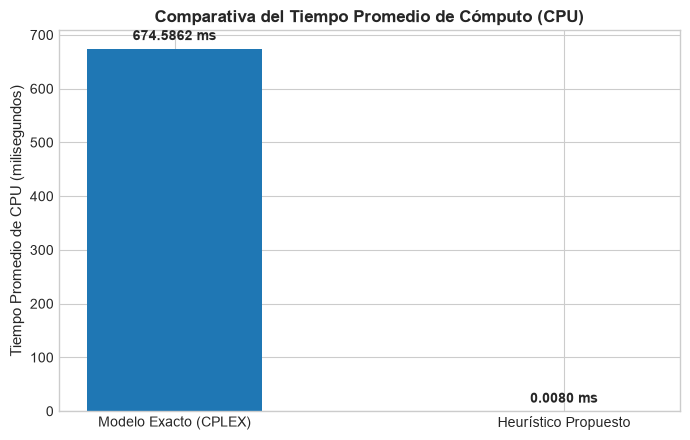

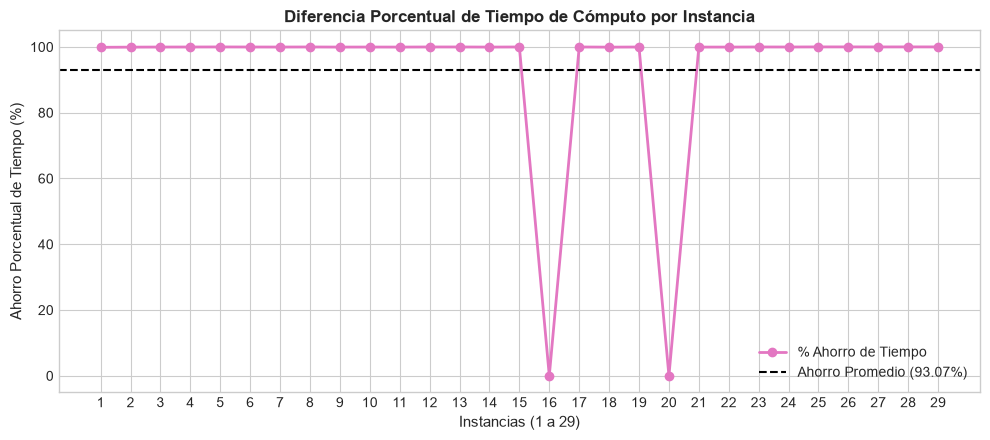

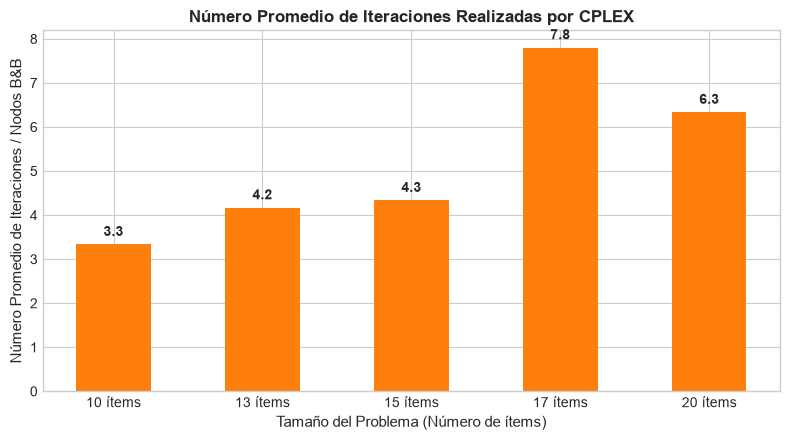

In [35]:
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)

fig, ax = plt.subplots(figsize=(7, 4.5))
proms_t_ms = [
    np.mean(tiempo_cpu) * 1000,
    np.mean(tiempo_ejecucion_h) * 1000,
]  # Convertir a ms

bars = ax.bar(
    ['Modelo Exacto (CPLEX)', 'Heurístico Propuesto'],
    proms_t_ms,
    color=['#1f77b4', '#2ca02c'],
    width=0.45,
)
ax.set_ylabel('Tiempo Promedio de CPU (milisegundos)', fontsize=11)
ax.set_title(
    'Comparativa del Tiempo Promedio de Cómputo (CPU)',
    fontsize=12,
    fontweight='bold',
)

for bar in bars:
  height = bar.get_height()
  ax.annotate(
      f'{height:.4f} ms',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 4),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontweight='bold',
  )

plt.tight_layout()
plt.savefig('../images/grafica_1_promedio_tiempos.png', dpi=300)
plt.show()


# ------------------------------------------
# Gráfica 2: Diferencia Porcentual de Tiempos por Instancia
# ------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4.5))
instancias_x = list(range(1, len(dif_porcentual_Tiempo) + 1))

ax.plot(
    instancias_x,
    dif_porcentual_Tiempo,
    marker='o',
    color='#e377c2',
    linewidth=2,
    label='% Ahorro de Tiempo',
)
ax.axhline(
    y=np.mean(dif_porcentual_Tiempo),
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Ahorro Promedio ({np.mean(dif_porcentual_Tiempo):.2f}%)',
)

ax.set_xlabel('Instancias (1 a 29)', fontsize=11)
ax.set_ylabel('Ahorro Porcentual de Tiempo (%)', fontsize=11)
ax.set_title(
    'Diferencia Porcentual de Tiempo de Cómputo por Instancia',
    fontsize=12,
    fontweight='bold',
)
ax.set_xticks(instancias_x)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../images/grafica_2_diferencia_porcentual_tiempo.png', dpi=300)
plt.show()


# ------------------------------------------
# Gráfica 3: Número Promedio de Iteraciones CPLEX por Tamaño
# ------------------------------------------
# Agrupar las 29 instancias por tamaño (10, 13, 15, 17, 20 ítems)
df_iteraciones = pd.DataFrame({
    'Tamaño_Instancia': (
        [10] * 6 + [13] * 6 + [15] * 6 + [17] * 5 + [20] * 6
    ),
    'Iteraciones': num_iteraciones,
})

iter_promedio_por_tamano = df_iteraciones.groupby('Tamaño_Instancia')[
    'Iteraciones'
].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars_iter = ax.bar(
    [f'{t} ítems' for t in iter_promedio_por_tamano.index],
    iter_promedio_por_tamano.values,
    color='#ff7f0e',
    width=0.5,
)

ax.set_xlabel('Tamaño del Problema (Número de ítems)', fontsize=11)
ax.set_ylabel('Número Promedio de Iteraciones / Nodos B&B', fontsize=11)
ax.set_title(
    'Número Promedio de Iteraciones Realizadas por CPLEX',
    fontsize=12,
    fontweight='bold',
)

for bar in bars_iter:
  height = bar.get_height()
  ax.annotate(
      f'{height:.1f}',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 4),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontweight='bold',
  )

plt.tight_layout()
plt.savefig('../images/grafica_3_iteraciones_cplex.png', dpi=300)
plt.show()